# Minimal working example 2 — Allen Neuropixels data

Fit **pop-GLM** to one Allen Brain Observatory – Neuropixels Visual Coding session and reproduce the
paper's central finding: **coupling from V1 to LM is reduced during locomotion**.

This is the model used for the main results: **six areas**, target = LM (`probeD`), with **coupling
from all six areas** (so V1→LM is conditioned on AL/RL/AM/PM), a **time-warped baseline**, a
**trial-wise gain** (`trial_coef`), and the nonlinear damping term `refractory_additive` (f_damp).
Populations are the condition-specific groups (`group_id==0`) pooled by `utils.pooling_pop`.

**Data.** `popglm_data.Dataset` reproduces `DataLoader.Allen_dataset` (session 757216464, the 14
stimulus conditions used in the paper → 210 trials, 81 running / 129 stationary; 0–500 ms with 300 ms
padding) by reading the session NWB directly with `h5py`. Build it once with
`revision_experiments/build_dataset.py`.

In [1]:
import os, sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))                       # repo root (GLM.py, utility_functions.py)
sys.path.insert(0, os.path.abspath("../revision_experiments"))  # popglm_data.py
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
import GLM, utility_functions as utils
from popglm_data import Dataset, load_membership

ds = Dataset(); MEMB, CIDS = load_membership()
PROBES = ['probeA','probeB','probeC','probeD','probeE','probeF']   # AM PM V1 LM AL RL
print("trials: %d   (running %d / stationary %d)"
      % (ds.ntrial, ds.running_trial_index.sum(), ds.stationary_trial_index.sum()))
print("pooled population spike trains (nt+padding, ntrial):",
      utils.pooling_pop(MEMB, CIDS, ds, 'probeC', 0).shape)

trials: 210   (running 81 / stationary 129)
pooled population spike trains (nt+padding, ntrial): (800, 210)


## Fit the model (target = LM), separately for running and stationary trials

Hyperparameters are those of the main analysis.

In [2]:
CP = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
def fit_LM(select_trials):
    m = GLM.PP_GLM(dataset=ds, select_trials=select_trials, membership=MEMB, condition_ids=CIDS)
    m.add_effect('inhomogeneous_baseline', num=20, apply_no_penalty=True)
    for p in PROBES:                                   # coupling from ALL six areas
        m.add_effect('coupling', p, apply_no_penalty=True, **CP)
    m.add_effect('refractory_additive', 'probeD', tau=15, num=4, apply_no_penalty=True)   # f_damp
    m.add_effect('trial_coef')                                                            # trial-wise gain
    m.fit_time_warping_baseline('probeD', verbose=False, max_iter=10, penalty=5e-1)
    return m

m_run  = fit_LM(ds.running_trial_index)
m_stat = fit_LM(ds.stationary_trial_index)
print("effect index 3 =", m_run.basis_name[3])         # 'coupling from V1'
g_run  = np.asarray(m_run.get_filter()[3])
g_stat = np.asarray(m_stat.get_filter()[3])
print("V1->LM coupling integral:   stationary = %.3f    running = %.3f" % (g_stat.sum(), g_run.sum()))

effect index 3 = coupling from V1
V1->LM coupling integral:   stationary = 1.942    running = 1.025


## Result — V1→LM coupling is reduced during locomotion

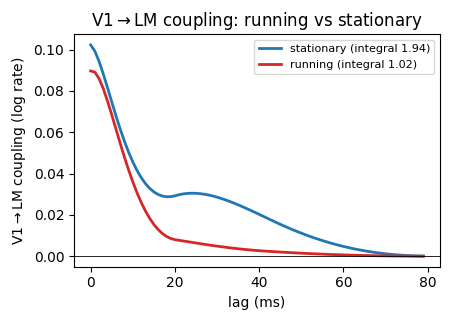

Coupling from V1 to LM is weaker during running -- the paper's main finding.
(The excursion + permutation test in the Methods assesses this difference formally.)


In [3]:
plt.figure(figsize=(4.6,3.3))
plt.plot(g_stat, color="#1f77b4", lw=2, label="stationary (integral %.2f)" % g_stat.sum())
plt.plot(g_run,  color="#d62728", lw=2, label="running (integral %.2f)"    % g_run.sum())
plt.axhline(0, color="k", lw=.6)
plt.xlabel("lag (ms)"); plt.ylabel("V1$\\to$LM coupling (log rate)")
plt.title("V1$\\to$LM coupling: running vs stationary"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Coupling from V1 to LM is weaker during running -- the paper's main finding.")
print("(The excursion + permutation test in the Methods assesses this difference formally.)")